# Implementing a Directed Message Passing Neural Network from scratch

This notebook will walk through the theory and implementation of the Directed Message Passing Neural Network (D-MPNN) introduced by "Analyzing Learned Molecular Representations for Property Prediction" Yang et al. 2019. 

The D-MPNN is a variant of the classic message passing neural network, where the fundamental unit of representation is the directed bond states instead of node states. This was specifically designed to overcome the tottering problem, where a message from node $u$ to $v$ is immedietly returned to the sender in subsequent message passing steps.
 

This notebook walks through the development of the pytorch implementation with the corresponding theory. Specifically, we:

1. Walk through the theory and implementation of initialization, message passing, updating, aggregating, and pooling functions of the D-MPNN on a single toy graph, making it easy to track how node and edge attributes are changing with each step. At each step we first do a logical brute force implementation, followed by a vectorized version. 
2. Show how we extend this to operate on a batch of graphs simulatneously with brute force. 
3. Generate some synthetic molecular graphs with a true target property based on node and edge features, and train a model on the graphs to see if it can learn this arbitrary rule. 
4. Tweak for GPU efficencies before implementing in dmpnn/model.py
5. Look into what this model learned using node and edge ablation scores on some sample molecules. 

## Input

Since the D-MPNN was developed for molecular property prediction, we'll use molecular graphs as the default use-case, but this can be applied to any decorated graph.

We represent a molecule as a 2-dimensional undirected graph $G = (V, E)$, where $V = \{v_1, \dots, v_N\}$ is the set of $N$ nodes (atoms) and $E \subseteq V \times V$ is the set of edges (chemical bonds). The structure is encoded by the adjacency matrix $\mathbf{A} \in \{0, 1\}^{N \times N}$. Associated with each node $v_i$ is a feature vector $\mathbf{x}_i \in \mathbb{R}^F$ (e.g., atomic number, hybridization), forming a node feature matrix $\mathbf{X} \in \mathbb{R}^{N \times F}$. Similarly, each edge $(i,j) \in E$ is associated with a bond feature vector $\mathbf{b}_{ij} \in \mathbb{R}^D$ (e.g., bond type or order), forming a bond feature tensor $\mathbf{B} \in \mathbb{R}^{N \times N \times D}$, where $\mathbf{B}_{ij\cdot} = \mathbf{b}_{ij}$ when $(i,j) \in E$ and is zero otherwise. The complete attributed graph is thus represented as $G = (\mathbf{A}, \mathbf{X}, \mathbf{B})$.

In practice, it's much simpler to have $\mathbf{B}\in\mathbb{R}^{E \times D}$, where the rows of this bond feature matrix are indexed by the corresponding edge. For a directed graph, this would become $\mathbf{B}\in\mathbb{R}^{2E \times D}$, where each directed edge corresponds to a row. This way edge $u$->$v$ can have a different feature vector than $v$->$u$.


In chemprop, the default atom features are atom type, number of bonds, formal charge, etc. . The categorical features are one-hot ecoded, giving a 133 dimensional defult feature vector for each atom. For bonds we have bond type, conjugation, ring membership, stereo. Giving a 14 dimensional feature default vector for each bond. These features are readily available in RDKit. So in our setup, if we imagine a 5-atom molecule as follows, we have $N=5$, $E=5$, $F=144$, $D=14$

X:  torch.Size([5, 4]) 
 tensor([[0, 0, 0, 0],
        [1, 1, 1, 1],
        [2, 2, 2, 2],
        [3, 3, 3, 3],
        [4, 4, 4, 4]]) 
B:  torch.Size([10, 3]) 
 tensor([[0, 0, 0],
        [1, 1, 1],
        [2, 2, 2],
        [3, 3, 3],
        [4, 4, 4],
        [5, 5, 5],
        [6, 6, 6],
        [7, 7, 7],
        [8, 8, 8],
        [9, 9, 9]]) 
edge_index:  torch.Size([2, 10]) 
 tensor([[0, 0, 1, 1, 2, 2, 3, 3, 3, 4],
        [1, 3, 0, 2, 1, 3, 0, 2, 4, 3]])


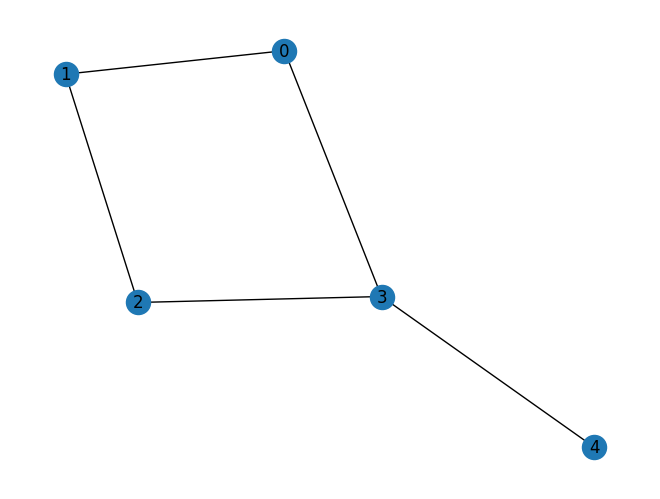

In [ ]:
import torch
import networkx as nx
torch.manual_seed(42)

#build a toy graph
N = 5   # num atoms
E = 5   # num edges
F = 4   # atom feature vec length
D = 3   # bond feature vec length
d = 6   # hidden dimension
c = F+D # concatenated atom-bond feat vec length, for convenience

A=torch.tensor([[0,1,0,1,0],
               [1,0,1,0,0],
               [0,1,0,1,0],
               [1,0,1,0,1],
               [0,0,0,1,0]]
               )


# draw graph based on A
G = nx.from_numpy_array(A.numpy())
nx.draw(G, with_labels=True)

# edge list 
edge_index = A.nonzero(as_tuple=False).T 
#  edge_index is a 2x2E tensor, where each column represents the index of a non-zero element in A.
#  Row 1=row index, Row 2=col index, Columns=edges

# generate the feature matrices with distinct values for each node and bond.
# these values are physically meaningless for now, but convenient for visually tracking what is going on
X = torch.arange(N).unsqueeze(1).expand(N, F) # atom feature matrix
B = torch.arange(2*E).unsqueeze(1).expand(2*E, D) # bond feature matrix

print("X: ", X.shape, "\n", X, "\nB: ", B.shape, "\n",B, "\nedge_index: ", edge_index.shape,"\n", edge_index)


In [ ]:
# For the D-MPNN, we are going to need the reverse edge mapping
# for each directed edge i = (u->v), what edge index corresponds to (v->u)?
src, rcv = edge_index

# first we'll make an edge index dict. zip the two tensors, then enumerate, to create an iterator
# that contains an index, and the tuple of the matching dimension pairs from the two tensors
edge_dict = {(u.item(), v.item()): i for i, (u,v) in enumerate(zip(src, rcv))}

#iterate over the zipped tensors, and assign the value (index) of the reverse edge
rev_index = torch.tensor([
edge_dict[(v.item(), u.item())] for u,v in zip(src,rcv)
])

#so now for each colum of edge index, the corresponding entry in rev_index points to the column of the reverse edge
edge_dict, edge_index, rev_index

({(0, 1): 0,
  (0, 3): 1,
  (1, 0): 2,
  (1, 2): 3,
  (2, 1): 4,
  (2, 3): 5,
  (3, 0): 6,
  (3, 2): 7,
  (3, 4): 8,
  (4, 3): 9},
 tensor([[0, 0, 1, 1, 2, 2, 3, 3, 3, 4],
         [1, 3, 0, 2, 1, 3, 0, 2, 4, 3]]),
 tensor([2, 6, 0, 4, 3, 7, 1, 5, 9, 8]))

## Initializing States
In the D-MPNN, we initialize the hidden states with the following:

$$
h_{vu}^{(0)} = \sigma\!\left(W_i [x_v \| b_{vu}]\right)
$$

where:

- $h_{vu}^{(0)}$ is the latent representation of the directed bond from node $v$ to $u$
- $x_v$ is the feature vector of the source node $v$
- $b_{vu}$ is the feature vector of the directed bond
- $W_i \in \mathbb{R}^{d \times c}$, is a learned initializing weight matrix to project representations into $\mathbb{R}^{d}$, where $d$ is the hidden dimension and $c$ is the dimension of the concatenated atom and bond feature vector

In [ ]:
#before we can initialize by doing this concatenation, we have B = [10,D], but X = [5,F]
#we need to get the atom feature vector for each source node of each directed edge (expand X to [10xF])
src=edge_index[0]
X_src = X[src] #[10,F]

#start by concatenating bond feat vectors to atom feat vectors
C = torch.cat([X_src,B], dim=1).float()
C.shape #[2E, D+F]
C

tensor([[0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 1., 1.],
        [1., 1., 1., 1., 2., 2., 2.],
        [1., 1., 1., 1., 3., 3., 3.],
        [2., 2., 2., 2., 4., 4., 4.],
        [2., 2., 2., 2., 5., 5., 5.],
        [3., 3., 3., 3., 6., 6., 6.],
        [3., 3., 3., 3., 7., 7., 7.],
        [3., 3., 3., 3., 8., 8., 8.],
        [4., 4., 4., 4., 9., 9., 9.]])

To compute the initial hidden states of all bonds in the molecule at one time using matrix notation:
$$
H^{(0)} = \sigma\!\left(CW_i^T\right)
$$

Where $H^{(0)}\in\mathbb{R}^{2E \times d}$ now contains the initial directed bond states. 

In [ ]:
# initialize weight matrix via Glorot initilization
# W_i = torch.empty(d,c)
# W_i = torch.nn.init.xavier_uniform_(W_i)

#for now, we will just initialize the weights with the identity so we can easily track values
W_i = torch.eye(d,c)

# H_0 = torch.relu(torch.matmul(C,W_i.T))
H_0 = torch.matmul(C,W_i.T) # ignore relu for now for tracking

def initialize_states(C, W_i):
    # return torch.relu(torch.matmul(C,W_i.T))
    return torch.matmul(C,W_i.T)

W_i, H_0

(tensor([[1., 0., 0., 0., 0., 0., 0.],
         [0., 1., 0., 0., 0., 0., 0.],
         [0., 0., 1., 0., 0., 0., 0.],
         [0., 0., 0., 1., 0., 0., 0.],
         [0., 0., 0., 0., 1., 0., 0.],
         [0., 0., 0., 0., 0., 1., 0.]]),
 tensor([[0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 1., 1.],
         [1., 1., 1., 1., 2., 2.],
         [1., 1., 1., 1., 3., 3.],
         [2., 2., 2., 2., 4., 4.],
         [2., 2., 2., 2., 5., 5.],
         [3., 3., 3., 3., 6., 6.],
         [3., 3., 3., 3., 7., 7.],
         [3., 3., 3., 3., 8., 8.],
         [4., 4., 4., 4., 9., 9.]]))

## Messages
The messages in the DMPNN are computed by:
$$
\mathbf{m}_{vu}^{(t+1)} = \sum_{k \in \mathcal{N}(v) \setminus \{u\}} \mathbf{h}_{kv}^{(t)}
$$

In words, the message of a directed bond from $v$ to $u$ is the sum of all latent bond representations of incoming bonds to $v$ EXCLUDING from node $u$. This is the distinction of the DMPNN, this exclusion avoids immediate message back passing. 

So to compute the matrix of messages $M$, for each directed bond from $u$->$v$, we need to sum all of the incoming bond states going into the source node $u$, then subtract the bond states of $v$->$u$. 

To do this, lets make sure we are clear on what the edge_index and rev_index are. For each column in edge_index, the corresponding entry in rev_index points to the column of edge_index that is the reverse edge.

For example below: the 0th col in edge_index has row0entry=0, row1entry=1. The 0th entry in rev_index points to the column index in edge_index that contains the reverse edge (2). The col index 2 entry in edge index is row0entry=1, row1entry=0 (the reverse edge.)


In [ ]:
print("edge_index:\n",edge_index)
print("rev_index:\n", rev_index)
print("src:\n",src)
print("rcv:\n", rcv)

edge_index:
 tensor([[0, 0, 1, 1, 2, 2, 3, 3, 3, 4],
        [1, 3, 0, 2, 1, 3, 0, 2, 4, 3]])
rev_index:
 tensor([2, 6, 0, 4, 3, 7, 1, 5, 9, 8])
src:
 tensor([0, 0, 1, 1, 2, 2, 3, 3, 3, 4])
rcv:
 tensor([1, 3, 0, 2, 1, 3, 0, 2, 4, 3])


In [91]:
# now we compute the "messages"
def compute_messages(H):
    #brute force loop
    M=torch.empty(H.shape[0],d) #initialize message matrix
    #loop over directed edges
    for i in range(H.shape[0]):
        v=src[i] #get source node
        m_vu = (rcv==v).nonzero(as_tuple=True)[0] #get indices of edges going into source node
        incoming_states = H[m_vu] #get corresponding states
        incoming_sum = incoming_states.sum(dim=0) #sum element-wise along rows

        #get the reverse hidden state
        reverse_state_index = rev_index[i] 
        reverse_state = H[reverse_state_index]

        #exclude reverse state from message
        m_vu = incoming_sum - reverse_state

        #update message matrix
        M[i]=m_vu
    return M 

# to vectorize, lets compute all at once, for all nodes, the sum of all the incoming 
# directed bond states. Then we just look up that nodewise sum for any edge source node,
# then subtract the reverse edge state.
# so we want to build an [N,d] tensor, where the ith row
# is the sum of incoming states into node i. use torch.index_add_() to do this efficiently

def compute_messages_vectorized(H):
    incoming_sum_per_node = torch.zeros(N,H.shape[1])
    incoming_sum_per_node.index_add_(0, rcv, H) #(dim, index, source)
    M = incoming_sum_per_node[src] - H[rev_index] #remove reverse states
    return M
                        

## Updates
So we have the initial "messages". Now we need to update the states accordingly. The D-MPNN uses the following update for a single hidden state:

\begin{equation}
    \mathbf{h}_{vu}^{(t+1)} = 
    \sigma\left(
        \mathbf{h}_{vu}^{(0)} + 
        \mathbf{W}_h \mathbf{m}_{vu}^{(t+1)}
    \right)
\end{equation}

so in matrix form:
$$H^{(t+1)}=\sigma\left(H^{(0)} + M^{(t+1)}W_h^T\right)$$

Note that regardless of the message passing step $t$, we're always adding back the initial state $\mathbf{h}_{vu}^{(0)}$. This is a $\textit{skip-connection}$ as opposed to the more commonly seen residual connection

In [92]:
def update(H_0,M):
    return torch.relu(H_0 + torch.matmul(M,W_h.T))

## Message Passing Loop
Now we'll walk through T message passing steps and we can watch how the states update. Since we use the identity weight matrix, the message passing should actually just truncate the last couple columns of the state matrix.

Edge index dictionary (edges are keys, values are the row index in H and M):
 {(0, 1): 0, (0, 3): 1, (1, 0): 2, (1, 2): 3, (2, 1): 4, (2, 3): 5, (3, 0): 6, (3, 2): 7, (3, 4): 8, (4, 3): 9}
Inital State Matrix H_0: 
 tensor([[0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 1.],
        [1., 1., 1., 1., 2., 2.],
        [1., 1., 1., 1., 3., 3.],
        [2., 2., 2., 2., 4., 4.],
        [2., 2., 2., 2., 5., 5.],
        [3., 3., 3., 3., 6., 6.],
        [3., 3., 3., 3., 7., 7.],
        [3., 3., 3., 3., 8., 8.],
        [4., 4., 4., 4., 9., 9.]])
Step 1:
M:  tensor([[ 3.,  3.,  3.,  3.,  6.,  6.],
        [ 1.,  1.,  1.,  1.,  2.,  2.],
        [ 2.,  2.,  2.,  2.,  4.,  4.],
        [ 0.,  0.,  0.,  0.,  0.,  0.],
        [ 3.,  3.,  3.,  3.,  7.,  7.],
        [ 1.,  1.,  1.,  1.,  3.,  3.],
        [ 6.,  6.,  6.,  6., 14., 14.],
        [ 4.,  4.,  4.,  4., 10., 10.],
        [ 2.,  2.,  2.,  2.,  6.,  6.],
        [ 0.,  0.,  0.,  0.,  0.,  0.]]) 
H:  tensor([[ 3.,  3.,  3.,  

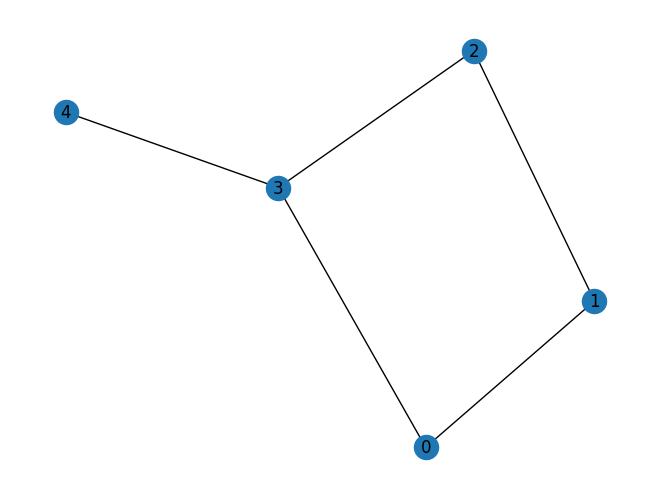

In [100]:
T = 3   # message passing steps
H = H_0.clone() 

# init randomizing weights
# W_h = torch.empty(d,d)
# W_h = torch.nn.init.xavier_uniform_(W_h)
W_h = torch.eye(d,d)

print("Edge index dictionary (edges are keys, values are the row index in H and M):\n",edge_dict)
print("Inital State Matrix H_0: \n", H_0)
for t in range(T):
    print(f"Step {t+1}:")
    M = compute_messages_vectorized(H)
    H = update(H_0,M) # skip connection, not residual connection
    print("M: ", M,"\nH: ", H)
nx.draw(G, with_labels=True)


Let's disect this to make sure it is working as intended.

### Tracking edge (3,2)
Lets first look at the edge from node 3 -> node 2 in the graph. Node 3 (the source) is connected to nodes 0, 4, and 2. We can find the initial state of the edge by finding the index in the edge dict: (3,2): 7. 

The i-7th row of H_0:

[3., 3., 3., 3., 7., 7.]. 

Recall these were arbitrarily chosen values. In practice, this would be some learned transformation ($W_h$) of the concatenated edge and feature vectors. So for this edge, we expect the "message" to be the sum of the states of edges (0,3), (4,3), (2,3) minus (2,3). 

Edge (0,3): 1, the i-1th row of H_0: [0., 0., 0., 0., 1., 1.],
Edge(4,3): 9, the i-9th row of H_0: [4., 4., 4., 4., 9., 9.].

So we would expect the message of the (2,3) to be the row-wise sum of these two: [4., 4., 4., 4., 10., 10.].

In Step 1, we can look at the i-7th row of M to see exactly this. The updated state vector should then be the initial state of (3,2): [3., 3., 3., 3., 7., 7.] plus some transformed version of this message.

We used the identity as the transform so nothing really changes, we would expect the updated state to be [3., 3., 3., 3., 7., 7.] + [4., 4., 4., 4., 10., 10.] = [ 7.,  7.,  7.,  7., 17., 17.].

Again, looking at the i-7th row of H in Step 1, this is exactly what we see. We can follow this along and see the pattern correctly continues.

### Terminal nodes
Another interesting case to look at: Edge (4,3). There are no edges that are going into the source node of this edge since node 4 is terminal. Then, according to the equations, we would expect the "message" from this edge to be empty, and so the updated state should just be the initial state at every step. In words, this edge has no information to propagate along to the other edges, so it just injects the information that it has (the initial state).

We can see that (4,3):9 has initial state [4., 4., 4., 4., 9., 9.],

the corresponding message in Step 1 is [ 0.,  0.,  0.,  0.,  0.,  0.], 

and the updated state in Step 1 is [4., 4., 4., 4., 9., 9.].

So this edge's state remains the same, but as we saw in the previous example, it contributed to the update of edge (3,2).

### Symmetry
A final point to notice. Due to the symmetry of this graph, we can see that several edges end up with the same final state vectors!
H:  tensor[
[10., 10., 10., 10., 23., 23.],
[ 6.,  6.,  6.,  6., 14., 14.],
[10., 10., 10., 10., 23., 23.],
[10., 10., 10., 10., 23., 23.],
[10., 10., 10., 10., 23., 23.],
[ 6.,  6.,  6.,  6., 14., 14.],
[10., 10., 10., 10., 23., 23.],
[10., 10., 10., 10., 23., 23.],
[ 9.,  9.,  9.,  9., 23., 23.],
[ 4.,  4.,  4.,  4.,  9.,  9.]
]

This makes intuitive sense, since we are injecting no randomness in this example. 

## Node Aggregation and Pooling

Now, before the graph-level pooling step, we need to aggregate these edge states back to node-level representations. The D-MPNN does this by summing over the incoming bonds, concatenating the original atom feature vector, then applying another linear transformation + relu. 

\begin{equation}
\mathbf{h}_u = \sigma \!\left( \mathbf{W}_a \left[ \mathbf{x}_u \,\|\, \sum_{v \in \mathcal{N}(u)} \mathbf{h}_{vu}^{(T)} \right] \right).
\end{equation}

Or in matrix form:

\begin{equation}
\mathbf{H}_\text{atom-aggd} = \sigma \!\left( \mathbf{R}\mathbf{W}_a^T \right)
\end{equation}

Where the u-th row of $\mathbf{R}$ is the (atom feat | incoming-summed-states) vector of the u-th atom.

In [102]:
def atom_aggregation(H, X, rcv):
    #loop over all atoms in molecule
    R=torch.empty(N,d+F)
    for u in range(N):
        m_vu = (rcv==u).nonzero(as_tuple=True)[0] #get indices of edges going into u
        incoming_states = H[m_vu] #get corresponding bond states
        incoming_sum = incoming_states.sum(dim=0) #sum
        atom_feat = X[u] #get atom feat vec
        x_h = torch.cat([atom_feat, incoming_sum])
        R[u]=x_h

        print("-"*100)
        print("m_uv:", m_vu.shape,"\n", m_vu)
        print("incoming_states: ", incoming_states.shape,"\n", incoming_states)
        print("incoming_sums: ", incoming_sum.shape,"\n", incoming_sum)
        print("atom_feat: ", atom_feat, atom_feat.shape)
        print("x_h: ", x_h.shape,"\n", x_h)
        print("R: ", R.shape,"\n", R)
    return R

# vectorize the back-to-atom-aggregation
def atom_aggregation_vectorized(H, X,rcv):
    incoming_sum_per_node = torch.zeros(X.shape[0], H.shape[1])
    incoming_sum_per_node.index_add_(0, rcv, H)
    R = torch.cat([X, incoming_sum_per_node], dim=1) #[N,F+d]
    return R


# W_a = torch.empty(d, d+F) #(the concatenated vector will be of length d (hidden dim) + F (atom feat vec length)), and we want it mapping back to R^d
# W_a = torch.nn.init.xavier_uniform_(W_a)
W_a = torch.eye(d, d+F)

R = atom_aggregation(H, X, rcv)
# P = torch.relu(torch.matmul(R, W_a.T))
P = torch.matmul(R, W_a.T)
print("P: ", P.shape,"\n", P)

z_G = torch.sum(P,dim=0)
print("z_G: ", z_G.shape,"\n", z_G)

R_vec = atom_aggregation_vectorized(H, X, rcv)
P_vec = torch.relu(torch.matmul(R_vec, W_a.T))
# P = torch.matmul(R, W_a.T)

z_G_vec = torch.sum(P_vec,dim=0)
print("z_G_vec: ", z_G.shape,"\n", z_G)

----------------------------------------------------------------------------------------------------
m_uv: torch.Size([2]) 
 tensor([2, 6])
incoming_states:  torch.Size([2, 6]) 
 tensor([[10., 10., 10., 10., 23., 23.],
        [10., 10., 10., 10., 23., 23.]])
incoming_sums:  torch.Size([6]) 
 tensor([20., 20., 20., 20., 46., 46.])
atom_feat:  tensor([0, 0, 0, 0]) torch.Size([4])
x_h:  torch.Size([10]) 
 tensor([ 0.,  0.,  0.,  0., 20., 20., 20., 20., 46., 46.])
R:  torch.Size([5, 10]) 
 tensor([[ 0.,  0.,  0.,  0., 20., 20., 20., 20., 46., 46.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.]])
----------------------------------------------------------------------------------------------------
m_uv: torch.Size([2]) 
 tensor([0, 4])
incoming_states:  torch.Size([2, 6]) 
 tensor([[10., 10., 10., 10.,

Again we can see above that everything is being aggregated as expected.

# Training loop
Let's start putting things into a pytorch module so we can build a little training loop. We are just copy and pasting the functions (vectorized) that we've just written. We write the model class and the desired functionality in forward(). We also write the 3 layer MLP head that takes the learned embedding $\mathbf{z}_G\in \mathbb{R}^d$ and produces a real valued output.

In [ ]:
import torch.nn as nn
class DMPNNEncoder(nn.Module):
    def __init__(self, node_feat_dim, edge_feat_dim, hidden_dim, num_steps):
        super().__init__()

        #global model params
        self.node_feat_dim = node_feat_dim
        self.edge_feat_dim = edge_feat_dim
        self.hidden_dim = hidden_dim
        self.num_steps = num_steps

        self.W_i = nn.Parameter(torch.empty(hidden_dim, node_feat_dim+edge_feat_dim))
        self.W_h = nn.Parameter(torch.empty(hidden_dim, hidden_dim))
        self.W_a = nn.Parameter(torch.empty(hidden_dim,hidden_dim+node_feat_dim))

        #initialize weight matrices
        torch.nn.init.xavier_uniform_(self.W_i)
        torch.nn.init.xavier_uniform_(self.W_h)
        torch.nn.init.xavier_uniform_(self.W_a)


    def initialize_edge_states(self, X, B, edge_index):
        src, rcv = edge_index
        edge_dict = {(u.item(), v.item()): i for i, (u,v) in enumerate(zip(src, rcv))}
        #iterate over the zipped tensors, and assign the value (index) of the reverse edge
        rev_index = torch.tensor([edge_dict[(v.item(), u.item())] for u,v in zip(src,rcv)])
        src=edge_index[0]
        X_src = X[src] #[2*E,F]
        C = torch.cat([X_src,B], dim=1).float()
        H_0 = torch.relu(torch.matmul(C, self.W_i.T))
        return H_0, src, rcv, rev_index

    def compute_messages(self, H, d, src, rcv, rev_index):
        #brute force loop
        M=torch.empty(H.shape[0],d)
        #loop over directed edges
        for i in range(2*E):
            v=src[i]
            u=rcv[i]
            m_vu = (rcv==v).nonzero(as_tuple=True)[0] #get indices of edges going into v
            incoming_states = H[m_vu]
            incoming_sum = incoming_states.sum(dim=0)

            #get the reverse hidden state
            reverse_state_index = rev_index[i] 
            reverse_state = H[reverse_state_index]
            m_vu = incoming_sum - reverse_state

            #update message tensor
            M[i]=m_vu
        return M
    
    def compute_messages_vectorized(self, H, X,  d, src, rcv, rev_index):
        incoming_sum_per_node = torch.zeros(X.shape[0],H.shape[1])
        incoming_sum_per_node.index_add_(0, rcv, H) #(dim, index, source)
        M = incoming_sum_per_node[src] - H[rev_index]
        return M

    def update(self, H_0, M):
        return torch.relu(H_0 + torch.matmul(M, self.W_h.T))


    def aggregate_to_nodes(self, H, X, N, rcv):
        R=torch.empty(N, self.hidden_dim+self.node_feat_dim)
        #loop over all atoms in molecule
        for u in range(N):
            m_vu = (rcv==u).nonzero(as_tuple=True)[0] #get indices of edges going into u
            incoming_states = H[m_vu] #get corresponding bond states
            incoming_sum = incoming_states.sum(dim=0) #sum

            atom_feat = X[u] #get atom feat vec
            x_h = torch.cat([atom_feat, incoming_sum])
            #apply projection
            R[u]=x_h

        P = torch.relu(torch.matmul(R, self.W_a.T))
        return P
    
    def aggregate_to_nodes_vectorized(self, H, X, rcv):
        incoming_sum_per_node = torch.zeros(X.shape[0], H.shape[1])
        incoming_sum_per_node.index_add_(0, rcv, H)
        R = torch.cat([X, incoming_sum_per_node], dim=1) #[N,F+d]
        P = torch.relu(torch.matmul(R, self.W_a.T))
        return P

    def node_pooling(self, P):
        return torch.sum(P,dim=0)


    def forward(self, X, B, edge_index):
        #initialize hidden states
        H_0, src, rcv, rev_index = self.initialize_edge_states(X, B, edge_index)
        H=H_0
        for _ in range(self.num_steps):
            M = self.compute_messages_vectorized(H, X, d = self.hidden_dim, src=src, rcv=rcv, rev_index=rev_index, )
            H = self.update(H_0, M) #skip connection, not residual connection

        P = self.aggregate_to_nodes_vectorized(H, X, rcv)
        
        z_G = self.node_pooling(P)
        return z_G


class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()

        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size,hidden_size)
        self.fc3 = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        return x
    


In [ ]:
# now rebuild toy graph, initialize, and run a little loop
N = 5 # num atoms
E = 5 # num edges
F = 4 # atom feature vec length
D = 3 # bond feature vec length
c=F+D #concatenated atom-bond feat vec length

#model params
d = 6 # dmpnn hidden dim
ffn_hidden_dim=10 #mlp hidden dim
output_dim=1 #response
y=2.5 #define a true value

A=torch.tensor([[0,1,0,1,0],
               [1,0,1,0,0],
               [0,1,0,1,0],
               [1,0,1,0,1],
               [0,0,0,1,0]]
               )

#get the edge list from here
edge_index = A.nonzero(as_tuple=False).T 
B=torch.rand(edge_index.shape[1], D)
# construct a random atom and bond feature matrix
X=torch.rand(N, F)


In [112]:
import numpy as np
import torch

torch.manual_seed(42)

def compute_mse_loss(y, y_hat):
    return torch.sum((y-y_hat)**2)

#instantiate
dmpnn = DMPNNEncoder(F, D, d, 3) #encoder
ffn = MLP(d, ffn_hidden_dim, output_dim) #decoder

#init
loss = np.inf
thresh=0.1
step=0
lr=10e-2
# optimizer = torch.optim.Adam(list(dmpnn.parameters())+list(ffn.parameters()), lr) # pass params to be optimized
optimizer = torch.optim.SGD(
    list(dmpnn.parameters()) + list(ffn.parameters()), lr=lr
) #using SGD for tracking

while loss>thresh:
    optimizer.zero_grad() #zero the gradients
    z = dmpnn(X, B, edge_index) #get encoder graph representation
    y_hat = ffn(z.unsqueeze(0)) #get a prediction from that representation
    
    if step==0:
        print(f"Initial W_h: {dmpnn.W_h}")
    elif step==1:
        print(f"After 1st update W_h: {dmpnn.W_h}")
    loss = compute_mse_loss(y,y_hat)
    loss.backward() # computes the gradients of the loss wrt all defined params dL/dW_a, dL/dW_i, dL/dW_h, dL/dW_mlp1, dL/dW_mlp2
    optimizer.step() # updates the parameter values using the gradients
    step+=1
    torch.set_printoptions(precision=2, sci_mode=False)
    print(f"step {step}, prediction: {y_hat.item():.4f}, ", f"loss={loss.item():.4f}, ", "z_G: ", z)
    if step==0 or step==1:
        print(f"\nW_h grads\n: {dmpnn.W_h.grad}")

    if loss<thresh:
        print(f"converged at step {step}")


Initial W_h: Parameter containing:
tensor([[ 0.30,  0.63,  0.41, -0.31,  0.41,  0.13],
        [ 0.36, -0.43, -0.70, -0.27, -0.54,  0.58],
        [ 0.20,  0.29,  0.22, -0.01,  0.55, -0.50],
        [ 0.04, -0.48,  0.22, -0.24,  0.22, -0.15],
        [ 0.59, -0.42, -0.42, -0.42,  0.64,  0.24],
        [ 0.68, -0.58, -0.70, -0.55, -0.48,  0.29]], requires_grad=True)
step 1, prediction: -0.7170,  loss=10.3488,  z_G:  tensor([18.38, 14.86,  0.00,  0.00,  0.00,  0.00], grad_fn=<SumBackward1>)

W_h grads
: tensor([[ 3.51,  2.00,  1.70,  0.01,  1.26,  1.62],
        [ 1.07,  0.07,  0.57,  0.01,  0.53,  0.32],
        [-3.70, -1.91, -1.80, -0.01, -1.35, -1.62],
        [-1.21, -0.35, -0.62, -0.01, -0.55, -0.46],
        [ 2.62,  0.68,  1.29,  0.02,  1.11,  0.81],
        [ 1.81,  1.35,  0.65,  0.00,  0.25,  0.64]])
After 1st update W_h: Parameter containing:
tensor([[-0.05,  0.43,  0.24, -0.31,  0.28, -0.04],
        [ 0.25, -0.44, -0.76, -0.27, -0.60,  0.55],
        [ 0.57,  0.48,  0.40, -0

In this little toy example we use vanilla stochastic gradient descent so that we can track updates. In SGD, the update is of the form: $w^{t+1}=w-\alpha \nabla{f_i(w^{(t)})}$. We set the learning rate, $\alpha$ to 0.1. looking at the [0,0] entry of W_h, initially we see 0.30.  the computed gradient is 3.51, so the updated parameter value in the next step should be 0.3-0.1*3.51=-0.0509, which we see as the new parameter value. Notice that the graph representation is all zeroes. This is ok. This example is completely meaningless, we are training a model on a single graph to predict a single value.

In [ ]:
# We can look at each of the final weight matrices
print("W_a: ", dmpnn.W_a, "\nW_h: ", dmpnn.W_h, "\nW_i: ", dmpnn.W_i)

W_a:  Parameter containing:
tensor([[ -23.71,  -19.26,  -26.38,  -17.08,  -43.30,   -4.85, -168.56,  -42.21,
           -0.79,   -4.06],
        [  -0.36,    0.14,    0.07,   -0.19,   -0.18,    0.33,   -0.71,   -0.34,
            0.26,   -0.32],
        [  -0.22,   -0.59,   -0.35,    0.15,   -0.08,   -0.44,    0.01,   -0.42,
           -0.52,   -0.34],
        [  -0.54,   -0.39,    0.61,    0.12,    0.19,   -0.57,   -0.40,   -0.20,
            0.10,   -0.54],
        [  -0.26,   -0.37,    0.00,   -0.23,   -0.04,   -0.41,   -0.42,   -0.36,
           -0.21,   -0.48],
        [   0.51,   -0.12,    0.53,    0.19,   -0.52,    0.42,   -0.17,   -0.23,
           -0.51,   -0.61]], requires_grad=True) 
W_h:  Parameter containing:
tensor([[ -28.50,  -12.74,  -89.95,  -15.58,   -2.67,   -5.24],
        [  -1.15,   -2.36,   -5.58,   -0.27,   -1.46,    0.55],
        [ -31.43,  -12.11, -100.15,  -17.78,   -2.65,   -5.76],
        [  12.14,    3.19,   38.22,    6.81,    1.33,    1.77],
        [   

## Batching

Now lets update this to accomodate computing this for multiple molecules at once. The neat trick here is actually to just treat all of the molecules as a single graph, but have no edges between them. Then we can just reuse all of the same message passing and update functions, we just need to adjust the pooling function to pool to individual molecules.

In [ ]:
import torch.nn as nn

class DMPNNEncoderBatch(nn.Module):
    def __init__(self, node_feat_dim, edge_feat_dim, hidden_dim, num_steps):
        super().__init__()

        self.node_feat_dim = node_feat_dim
        self.edge_feat_dim = edge_feat_dim
        self.hidden_dim = hidden_dim
        self.num_steps = num_steps

        self.W_i = nn.Parameter(torch.empty(hidden_dim, node_feat_dim+edge_feat_dim))
        self.W_h = nn.Parameter(torch.empty(hidden_dim, hidden_dim))
        self.W_a = nn.Parameter(torch.empty(hidden_dim,hidden_dim+node_feat_dim))

        #initialize weight matrices
        torch.nn.init.xavier_uniform_(self.W_i)
        torch.nn.init.xavier_uniform_(self.W_h)
        torch.nn.init.xavier_uniform_(self.W_a)


    def initialize_edge_states(self, X, B, edge_index):
        src, rcv = edge_index
        X_src = X[src] #[2E,F]
        C = torch.cat([X_src,B], dim=1)
        H_0 = torch.relu(torch.matmul(C, self.W_i.T))
        return H_0, src, rcv


    def compute_messages(self, H, X, src, rcv, rev_index):
        incoming_sum_per_node = torch.zeros(
            X.shape[0],
            H.shape[1],
            dtype=H.dtype,
            device=H.device,
        )
        incoming_sum_per_node.index_add_(0, rcv, H) #(dim, index, source)
        M = incoming_sum_per_node[src] - H[rev_index]
        return M


    def update(self, H_0, M):
        return torch.relu(H_0 + torch.matmul(M, self.W_h.T))

    
    def aggregate_to_nodes(self, H, X, rcv):
        incoming_sum_per_node = torch.zeros(
            X.shape[0],
            H.shape[1],
            dtype=H.dtype,
            device=H.device,
        )
        incoming_sum_per_node.index_add_(0, rcv, H)
        R = torch.cat([X, incoming_sum_per_node], dim=1) #[N,F+d]
        P = torch.relu(torch.matmul(R, self.W_a.T))
        return P

    #updated to take in a batch vector indicating how to pool the molecules.
    def node_pooling(self, P, batch_vec):
        num_graphs = batch_vec.max().item() + 1
        Z_G = torch.zeros(
            num_graphs,
            P.shape[1],
            dtype=P.dtype,
            device=P.device,
        )
        Z_G.index_add_(0, batch_vec, P) #vectorized node pooling
        return Z_G


    def forward(self, X, B, edge_index, rev_index, batch_vec):
        #initialize hidden states
        H_0, src, rcv = self.initialize_edge_states(X, B, edge_index)
        H=H_0
        for _ in range(self.num_steps):
            M = self.compute_messages(H, X, src=src, rcv=rcv, rev_index=rev_index)
            H = self.update(H_0, M) #skip connection, not residual connection
        P = self.aggregate_to_nodes(H, X, rcv)
        Z_G = self.node_pooling(P, batch_vec)
        return Z_G


class MLP(nn.Module):
    def __init__(self, input_size,  hidden_size, output_size):
        super().__init__()

        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size,hidden_size)
        self.fc3 = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        return x

## Simulation
Let's make a batch of 20 graphs or so, with a fixed equation for generating the response based on the features of the graph and see if the model can learn it. Here we write the functions to generate synthetic graphs and a corresponding target based on the node and edge features. We also write the batching function

In [113]:
import random
import torch
torch.manual_seed(42)
random.seed(42)
rng=random.Random(42)

# convert undirected edges/features -> directed
def make_directed(edges_undir, edge_feat_undir):
    src, rcv, feats = [], [], []
    for i, (u, v) in enumerate(edges_undir):
        src.extend([u, v])
        rcv.extend([v, u])
        feats.append(edge_feat_undir[i])
        feats.append(edge_feat_undir[i])

    edge_index = torch.tensor([src, rcv], dtype=torch.long)
    B = torch.stack(feats).float()
    return edge_index, B

# build adjacency from undirected edge list
def make_adjacency(num_nodes, edges_undir):
    A = torch.zeros(num_nodes, num_nodes, dtype=torch.float32)
    for u, v in edges_undir:
        A[u, v] = 1.0
        A[v, u] = 1.0
    return A


# Fixed target rule
#    y = 2*(# double bonds touching oxygen)
#      + 1*(# C-N adjacencies)
#      - 0.5*(# charged atoms)
def compute_target(X, edges_undir, E_undir):
    y = 0.0
    # count charged atoms
    num_charged = int(X[:, 3].sum().item())
    for i, (u, v) in enumerate(edges_undir):
        bond_feat = E_undir[i]

        is_double = bond_feat[1].item() > 0.5

        u_is_O = X[u, 1].item() > 0.5
        v_is_O = X[v, 1].item() > 0.5

        u_is_C = X[u, 0].item() > 0.5
        v_is_C = X[v, 0].item() > 0.5

        u_is_N = X[u, 2].item() > 0.5
        v_is_N = X[v, 2].item() > 0.5

        if is_double and (u_is_O or v_is_O):
            y += 2.0

        if (u_is_C and v_is_N) or (u_is_N and v_is_C):
            y += 1.0

    y -= 0.5 * num_charged
    return torch.tensor([y], dtype=torch.float32)



# build one graph record
def build_graph(X, edges_undir, E_undir):
    A = make_adjacency(X.shape[0], edges_undir)
    edge_index, B = make_directed(edges_undir, E_undir)
    y = compute_target(X, edges_undir, E_undir)

    return {
        "A": A,
        "X": X.float(),
        "edges_undir": edges_undir,
        "E_undir": E_undir.float(),
        "edge_index": edge_index,
        "B": B,
        "y": y,
    }

# batch a list of graphs
def batch_graphs(graphs):
    X_list = []
    B_list = []
    edge_index_list = []
    y_list = []
    batch_list = []

    node_offset = 0

    for graph_id, g in enumerate(graphs):
        X = g["X"]
        B = g["B"]
        edge_index = g["edge_index"]
        y = g["y"]

        X_list.append(X)
        B_list.append(B)
        edge_index_list.append(edge_index + node_offset)
        y_list.append(y)
        batch_list.append(torch.full((X.shape[0],), graph_id, dtype=torch.long))

        node_offset += X.shape[0]

    X_batch = torch.vstack(X_list)
    B_batch = torch.vstack(B_list)
    edge_index_batch = torch.cat(edge_index_list, dim=1)
    y_batch = torch.vstack(y_list)          # shape [num_graphs, 1]
    batch_vec = torch.cat(batch_list)       # shape [num_nodes_total]

    src, rcv = edge_index_batch
    edge_dict = {(u.item(), v.item()): i for i, (u,v) in enumerate(zip(src, rcv))}

    #iterate over the zipped tensors, and assign the value (index) of the reverse edge
    rev_index = torch.tensor(
        [edge_dict[(v.item(), u.item())] for u, v in zip(src, rcv)],
        dtype=torch.long,
    )

    return X_batch, B_batch, edge_index_batch, rev_index, y_batch, batch_vec


def random_node_feature(rng):
    # one of C, O, N
    atom_type = rng.choice(["C", "O", "N"])
    charge = rng.choice([0., 0., 0., 1.])  # mostly uncharged

    if atom_type == "C":
        return [1., 0., 0., charge]
    elif atom_type == "O":
        return [0., 1., 0., charge]
    else:
        return [0., 0., 1., charge]


def random_bond_feature(rng):
    # mostly single, sometimes double
    is_double = rng.random() < 0.3
    if is_double:
        return [0., 1.]
    return [1., 0.]


def generate_random_chain_graph(rng, min_nodes=3, max_nodes=5):
    num_nodes = random.randint(min_nodes, max_nodes)

    X = torch.tensor([random_node_feature(rng) for _ in range(num_nodes)], dtype=torch.float32)

    # simple connected chain
    edges_undir = [(i, i + 1) for i in range(num_nodes - 1)]

    E_undir = torch.tensor(
        [random_bond_feature(rng) for _ in edges_undir],
        dtype=torch.float32
    )

    return build_graph(X, edges_undir, E_undir)


def generate_random_graph(
    rng,
    min_nodes=3,
    max_nodes=10,
    extra_edge_prob=0.25,
    max_extra_edges=None
):
    num_nodes = rng.randint(min_nodes, max_nodes)

    X = torch.tensor(
        [random_node_feature(rng) for _ in range(num_nodes)],
        dtype=torch.float32
    )

    # make a random connected tree
    edges_set = set()
    for new_node in range(1, num_nodes):
        attach_to = rng.randint(0, new_node - 1)
        u, v = sorted((new_node, attach_to))
        edges_set.add((u, v))

    # adding extra edges to create cycles/rings
    possible_extra = []
    for u in range(num_nodes):
        for v in range(u + 1, num_nodes):
            if (u, v) not in edges_set:
                possible_extra.append((u, v))

    rng.shuffle(possible_extra)

    if max_extra_edges is None:
        max_extra_edges = max(1, num_nodes // 3)

    num_added = 0
    for (u, v) in possible_extra:
        if num_added >= max_extra_edges:
            break
        if rng.random() < extra_edge_prob:
            edges_set.add((u, v))
            num_added += 1

    edges_undir = sorted(edges_set)

    E_undir = torch.tensor(
        [random_bond_feature(rng) for _ in edges_undir],
        dtype=torch.float32
    )

    return build_graph(X, edges_undir, E_undir)


def compute_mse_loss(y, y_hat):
    return torch.mean((y-y_hat)**2)


def graph_signature(graph):
    X = graph["X"]
    edges = graph["edges_undir"]
    E = graph["E_undir"]

    node_part = tuple(tuple(x.tolist()) for x in X)

    edge_items = []
    for i, (u, v) in enumerate(edges):
        a, b = sorted((u, v))
        edge_items.append((a, b, tuple(E[i].tolist())))

    edge_part = tuple(sorted(edge_items))
    return (node_part, edge_part)


def generate_unique_graphs(n, existing_sigs=None, min_nodes=3, max_nodes=10, seed=42):
    rng = random.Random(seed)
    graphs = []
    sigs = set() if existing_sigs is None else set(existing_sigs)

    while len(graphs) < n:
        g = generate_random_graph(rng, min_nodes=min_nodes, max_nodes=max_nodes)
        sig = graph_signature(g)

        if sig not in sigs:
            graphs.append(g)
            sigs.add(sig)

    return graphs, sigs


def move_batch_to_device(X, B, edge_index, rev_index, y, batch_vec, device):
    return (
        X.to(device),
        B.to(device),
        edge_index.to(device),
        rev_index.to(device),
        y.to(device),
        batch_vec.to(device),
    )


def build_rev_index(edge_index: torch.Tensor) -> torch.Tensor:
    src, rcv = edge_index  # shape [E]

    # map (u,v) -> index
    edge_dict = {
        (int(u), int(v)): i
        for i, (u, v) in enumerate(zip(src.tolist(), rcv.tolist()))
    }

    # for each edge (u,v), find index of (v,u)
    rev_index = torch.tensor(
        [edge_dict[(int(v), int(u))] for u, v in zip(src.tolist(), rcv.tolist())],
        dtype=torch.long,
        device=edge_index.device,
    )

    return rev_index

In [ ]:
#example graphs
train_graphs, train_sigs = generate_unique_graphs(10, min_nodes=3, max_nodes=10, seed=42)

X_batch, B_batch, edge_index_batch, rev_index_batch,  y_batch, batch_vec= batch_graphs(train_graphs)

train_graphs[:3]

[{'A': tensor([[0., 1., 1., 1.],
          [1., 0., 0., 1.],
          [1., 0., 0., 0.],
          [1., 1., 0., 0.]]),
  'X': tensor([[1., 0., 0., 0.],
          [1., 0., 0., 0.],
          [1., 0., 0., 0.],
          [0., 0., 1., 0.]]),
  'edges_undir': [(0, 1), (0, 2), (0, 3), (1, 3)],
  'E_undir': tensor([[1., 0.],
          [1., 0.],
          [1., 0.],
          [1., 0.]]),
  'edge_index': tensor([[0, 1, 0, 2, 0, 3, 1, 3],
          [1, 0, 2, 0, 3, 0, 3, 1]]),
  'B': tensor([[1., 0.],
          [1., 0.],
          [1., 0.],
          [1., 0.],
          [1., 0.],
          [1., 0.],
          [1., 0.],
          [1., 0.]]),
  'y': tensor([2.])},
 {'A': tensor([[0., 1., 0., 1., 0., 0., 1., 1., 0.],
          [1., 0., 1., 1., 0., 0., 1., 0., 1.],
          [0., 1., 0., 0., 0., 0., 0., 0., 0.],
          [1., 1., 0., 0., 1., 0., 0., 1., 0.],
          [0., 0., 0., 1., 0., 1., 0., 0., 0.],
          [0., 0., 0., 0., 1., 0., 0., 0., 0.],
          [1., 1., 0., 0., 0., 0., 0., 0., 0.],


In [ ]:
import torch
import sys, os
sys.path.append(os.path.abspath(".."))

# define the device. CPU is good enough for small batches and graphs. 
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS (GPU)")
else:
    device = torch.device("cpu")
    print("MPS not available, using CPU")

# device = torch.device("cpu")

train_graphs, train_sigs = generate_unique_graphs(10000, min_nodes=3, max_nodes=8, seed=42)
test_graphs, _ = generate_unique_graphs(1000, min_nodes=3, max_nodes=8, existing_sigs=train_sigs, seed=43)

X_batch, B_batch, edge_index_batch, rev_index_batch,  y_batch, batch_vec = batch_graphs(train_graphs)
X_test, B_test, edge_index_test, rev_index_test_batch, y_test, batch_vec_test = batch_graphs(test_graphs)

#move to device
X_batch, B_batch, edge_index_batch, rev_index_batch, y_batch, batch_vec = move_batch_to_device(
    X_batch, B_batch, edge_index_batch, rev_index_batch, y_batch, batch_vec, device
)

X_test, B_test, edge_index_test, rev_index_test_batch, y_test, batch_vec_test = move_batch_to_device(
    X_test, B_test, edge_index_test, rev_index_test_batch, y_test, batch_vec_test, device
)

#params
F = X_batch.shape[1] # atom feature vec length
D = B_batch.shape[1] # bond feature vec length
c = F+D #concatenated atom-bond feat vec length
d = 128 #hidden dimension
ffn_hidden_dim=128
output_dim=1

#instantiate models and move to device
dmpnn = DMPNNEncoderBatch(F, D, d, 3).to(device)
ffn = MLP(d, ffn_hidden_dim, output_dim).to(device)

thresh=0.01
lr=1e-2
optimizer = torch.optim.Adam(list(dmpnn.parameters())+list(ffn.parameters()), lr=lr)
losses=[]
num_steps = 1000

for step in range(num_steps):
    optimizer.zero_grad()
    Z = dmpnn(X_batch, B_batch, edge_index_batch, rev_index_batch, batch_vec)
    y_hat = ffn(Z)

    loss = compute_mse_loss(y_batch,y_hat)
    loss.backward()

    losses.append(loss.item())
    optimizer.step()
    if step % 50 == 0:
        print(
            f"step {step}, loss={loss.item():.4}, prediction: {y_hat.squeeze().tolist()}"
        )

    if loss.item()<thresh:
        print(f"converged at step {step}")
        print("[pred, true]:\n", torch.cat([y_hat[:10], y_batch[:10]], dim=1))
        break

Using MPS (GPU)
step 0, loss=11.95, prediction: [-0.04960387200117111, -0.017541659995913506, -0.050601400434970856, 0.03626502305269241, -0.029674535617232323, 0.00046860799193382263, -0.039590828120708466, 0.02053345926105976, -0.002192426472902298, -0.00867941789329052, -0.0033311042934656143, 0.009640863165259361, -0.0022870246320962906, -0.09451206028461456, -0.026118969544768333, 0.010938460007309914, -0.22869804501533508, -0.0024273134768009186, 0.026505356654524803, -0.02604544721543789, -0.041357897222042084, 0.004009103402495384, 0.0042094215750694275, -0.06490367650985718, -0.002858741208910942, -0.004980826750397682, 0.03500642627477646, -0.013461919501423836, -0.03271767497062683, 0.0029451679438352585, -0.014803797006607056, -0.06625785678625107, -0.09776487201452255, -0.0034656208008527756, 0.007088067010045052, -0.026118380948901176, -0.0640888586640358, -0.02503815107047558, 0.00496293231844902, -0.05769418925046921, -0.11903555691242218, -0.055770084261894226, -0.0682

I found this to be a great introductory resource for improving GPU performance:
 
[Making GPUs Actually Fast](https://www.janestreet.com/tech-talks/making-gpus-actually-fast/) Sylvain Gugger & Corwin de Zahr - Jane Street

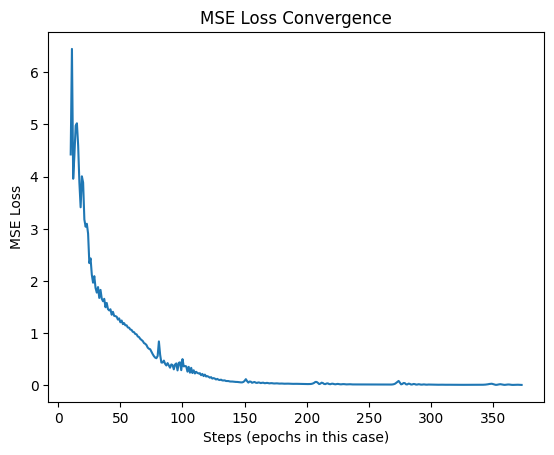

In [121]:
import matplotlib.pyplot as plt
#plot the loss function
steps=[]
for step, loss in enumerate(losses):
    steps.append(step)

plt.plot(steps[10:], losses[10:])
plt.title("MSE Loss Convergence")
plt.xlabel("Steps (epochs in this case)")
plt.ylabel("MSE Loss")
plt.show()

In [122]:
#check for duplicates between train and test
duplicates = []
for i, g in enumerate(test_graphs):
    sig = graph_signature(g)
    if sig in train_sigs:
        duplicates.append(i)

print(f"{len(duplicates)} / {len(test_graphs)} test graphs appear in training set")
print("duplicate indices:", duplicates)

0 / 1000 test graphs appear in training set
duplicate indices: []


In [126]:
# make a prediction using the trained model (.no_grad() stops the gradients from being computed)
with torch.no_grad():
    Z_test = dmpnn(X_test, B_test, edge_index_test, rev_index_test_batch, batch_vec_test).to(device)
    y_test_hat = ffn(Z_test).to(device)

def compute_mae_loss(y, y_hat):
    return torch.mean(torch.abs(y - y_hat))

print(f"Test MAE Loss: {compute_mae_loss(y_test, y_test_hat).item():.4f}")
print(f"Test MSE Loss: {compute_mse_loss(y_test, y_test_hat).item():.4f}")
print("y_test_hat:", [round(x, 2) for x in y_test_hat.squeeze().tolist()])
print("y_test_true:", y_test.squeeze().tolist())

Test MAE Loss: 0.0909
Test MSE Loss: 0.0164
y_test_hat: [2.06, 3.5, 7.89, 5.62, 1.42, 0.14, 2.52, 8.56, 3.97, -0.95, 9.07, 6.72, 2.47, 5.96, -1.01, 2.07, 4.04, 5.4, 4.87, 4.53, 3.06, 3.4, 4.98, 1.83, 3.4, 1.48, 1.58, -0.51, -0.64, 2.61, -0.32, 0.47, 0.47, 1.88, 4.52, -0.06, -0.44, 1.1, 4.76, 4.46, 3.99, 5.96, 2.75, 3.88, 7.99, 1.51, 6.37, 3.02, -1.01, 3.67, -0.05, 1.48, 5.47, 2.41, -0.46, 5.96, 10.32, -0.46, 2.19, 1.45, -1.54, 0.98, 2.06, 0.1, 4.04, 1.52, 4.96, 1.44, 2.99, 3.96, 7.43, 3.12, 1.67, 3.81, 1.51, 2.52, 6.97, 1.0, 1.53, 3.54, 2.03, 1.57, -0.56, 0.51, 0.98, 2.54, 3.48, 4.58, 1.48, 2.44, 7.03, 3.08, 3.48, -0.04, 0.97, 2.62, 1.08, 2.91, 4.41, 1.03, 3.35, 1.5, 0.42, 1.06, 2.06, 5.54, 3.61, 2.49, 1.07, 0.62, 2.59, 3.02, 4.59, 1.99, 2.49, 3.57, 0.94, 6.0, 4.1, 0.54, 1.08, 1.15, 4.93, -0.52, 3.83, 3.15, 2.94, 2.51, 2.99, 3.56, 3.34, 0.06, 0.9, 0.18, 2.97, 1.1, 4.89, 4.05, 3.98, -0.44, 2.89, 2.56, 2.08, 2.45, 3.53, 4.61, 2.61, 1.43, 3.06, 1.53, 5.62, 4.04, 2.97, 5.24, 0.86, 1.51, 4.

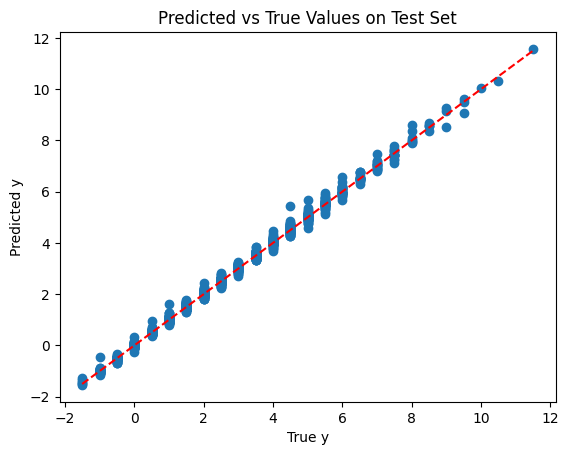

In [127]:
#plot y_test_hat vs y_test
import matplotlib.pyplot as plt
plt.scatter(y_test.squeeze().tolist(), y_test_hat.squeeze().tolist())
plt.xlabel("True y")
plt.ylabel("Predicted y")
plt.title("Predicted vs True Values on Test Set")
plt.plot([y_test.cpu().min(), y_test.cpu().max()], [y_test.cpu().min(), y_test.cpu().max()], 'r--')  # line y=x for reference
plt.show()

So the model trained on 10000 graphs between 3 and 8 nodes does a pretty good job on unsen graphs from the same distribution. It would be nice to see if the model is actually learning to decipher the target pattern, or just guessing well. Since we know exactly how the target is generated:

y = 2*(# double bonds touching oxygen) + 1*(# C-N adjacencies) - 0.5*(# charged atoms)

Then for a few test molecules, lets remove each node and edge, one at a time, and repredict using the trained model, to see how the fitted model's predictions change according to each item. This will give us an idea of how the model is valuing each piece.

In [149]:
import torch
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors


def predict_single_graph(dmpnn, ffn, X, B, edge_index, rev_index):
    dmpnn.eval()
    ffn.eval()

    batch_vec = torch.zeros(X.shape[0], dtype=torch.long, device=X.device)

    with torch.no_grad():
        Z = dmpnn(X, B, edge_index, rev_index, batch_vec)
        y_hat = ffn(Z)

    return y_hat.item()


def node_ablation_scores(dmpnn, ffn, X, B, edge_index, rev_index):
    base_pred = predict_single_graph(dmpnn, ffn, X, B, edge_index, rev_index)
    scores = torch.zeros(X.shape[0], dtype=X.dtype, device=X.device)

    for i in range(X.shape[0]):
        X_abl = X.clone()
        X_abl[i] = 0.0
        pred_i = predict_single_graph(dmpnn, ffn, X_abl, B, edge_index, rev_index)
        scores[i] = base_pred - pred_i

    return base_pred, scores


def bond_ablation_scores(dmpnn, ffn, X, B, edge_index, rev_index):
    base_pred = predict_single_graph(dmpnn, ffn, X, B, edge_index, rev_index)

    scores_dir = torch.zeros(B.shape[0], dtype=B.dtype, device=B.device)
    visited = set()

    for i in range(B.shape[0]):
        if i in visited:
            continue

        j = int(rev_index[i].item())

        B_abl = B.clone()
        B_abl[i] = 0.0
        B_abl[j] = 0.0

        pred_ij = predict_single_graph(dmpnn, ffn, X, B_abl, edge_index, rev_index)
        delta = base_pred - pred_ij

        scores_dir[i] = delta
        scores_dir[j] = delta

        visited.add(i)
        visited.add(j)

    return base_pred, scores_dir


def directed_to_undirected(edge_index, rev_index, B, bond_scores_dir=None):
    # for plotting / reporting, so convert to CPU here.
    src = edge_index[0].detach().cpu()
    rcv = edge_index[1].detach().cpu()
    rev_index = rev_index.detach().cpu()
    B = B.detach().cpu()

    undir_edges = []
    undir_feats = []
    undir_scores = []

    visited = set()

    for i in range(edge_index.shape[1]):
        if i in visited:
            continue

        j = int(rev_index[i].item())
        u = int(src[i].item())
        v = int(rcv[i].item())

        undir_edges.append((u, v))
        undir_feats.append(B[i])

        if bond_scores_dir is not None:
            undir_scores.append(float(bond_scores_dir[i].detach().cpu().item()))

        visited.add(i)
        visited.add(j)

    if bond_scores_dir is not None:
        return undir_edges, undir_feats, undir_scores
    return undir_edges, undir_feats


def atom_label(x_row):
    x_row = x_row.detach().cpu()

    is_c = x_row[0] > 0.5
    is_o = x_row[1] > 0.5
    is_n = x_row[2] > 0.5
    charged = x_row[3] > 0.5

    if is_c:
        label = "C"
    elif is_o:
        label = "O"
    elif is_n:
        label = "N"
    else:
        label = "?"

    if charged:
        label += "+"
    return label


def bond_label(b_row):
    b_row = b_row.detach().cpu()
    if b_row[1] > 0.5:
        return "="
    return "-"


def plot_graph_importance(graph, dmpnn, ffn, title_prefix=""):
    model_device = next(dmpnn.parameters()).device

    X = graph["X"].to(model_device)
    B = graph["B"].to(model_device)
    edge_index = graph["edge_index"].to(model_device)
    rev_index = graph["rev_index"].to(model_device)
    y_true = float(graph["y"].item())

    # model-based ablation contributions
    pred, node_scores = node_ablation_scores(dmpnn, ffn, X, B, edge_index, rev_index)
    _, bond_scores_dir = bond_ablation_scores(dmpnn, ffn, X, B, edge_index, rev_index)

    # convert directed bond scores to undirected bond scores for plotting
    undir_edges, undir_feats, undir_scores = directed_to_undirected(
        edge_index, rev_index, B, bond_scores_dir
    )
    undir_scores_t = torch.tensor(undir_scores, dtype=torch.float32)

    G = nx.Graph()
    for i in range(X.shape[0]):
        G.add_node(i, label=atom_label(X[i]))

    for (u, v), feat in zip(undir_edges, undir_feats):
        G.add_edge(u, v, label=bond_label(feat))

    pos = nx.spring_layout(G, seed=7)

    # raw model-attribution colors
    node_scores_np = node_scores.detach().cpu().numpy()
    node_colors = node_scores_np
    edge_colors = undir_scores_t.tolist()

    fig, ax = plt.subplots(figsize=(7, 5))

    # diverging color scales centered at 0
    node_absmax = max(abs(node_scores_np.min()), abs(node_scores_np.max()), 1e-8)
    node_norm = mcolors.TwoSlopeNorm(vmin=-node_absmax, vcenter=0.0, vmax=node_absmax)
    node_cmap = plt.cm.coolwarm

    edge_absmax = max(abs(undir_scores_t.min().item()), abs(undir_scores_t.max().item()), 1e-8)
    edge_norm = mcolors.TwoSlopeNorm(vmin=-edge_absmax, vcenter=0.0, vmax=edge_absmax)
    edge_cmap = plt.cm.coolwarm

    nx.draw_networkx_nodes(
        G,
        pos,
        node_color=node_colors,
        cmap=node_cmap,
        vmin=node_norm.vmin,
        vmax=node_norm.vmax,
        node_size=200,
        ax=ax,
    )

    nx.draw_networkx_edges(
        G,
        pos,
        edge_color=edge_colors,
        edge_cmap=edge_cmap,
        edge_vmin=edge_norm.vmin,
        edge_vmax=edge_norm.vmax,
        width=5,
        ax=ax,
    )

    nx.draw_networkx_labels(
        G,
        pos,
        labels={i: atom_label(X[i]) for i in range(X.shape[0])},
        font_size=10,
        ax=ax,
    )

    edge_label_dict = {(u, v): G[u][v]["label"] for u, v in G.edges()}
    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=edge_label_dict,
        font_size=12,
        ax=ax,
    )

    sm_nodes = cm.ScalarMappable(norm=node_norm, cmap=node_cmap)
    sm_nodes.set_array([])
    cbar_nodes = fig.colorbar(sm_nodes, ax=ax)
    cbar_nodes.set_label("Node contribution")

    sm_edges = cm.ScalarMappable(norm=edge_norm, cmap=edge_cmap)
    sm_edges.set_array([])
    cbar_edges = fig.colorbar(sm_edges, ax=ax)
    cbar_edges.set_label("Edge contribution")

    ax.set_title(
        f"{title_prefix}true={y_true:.2f}, pred={pred:.2f}\n"
    )

    rule_text = (
        "Target rule:\n"
        "+2 for every double bond involving O\n"
        "+1 for every C-N bond\n"
        "-0.5 for every charged node"
    )

    ax.annotate(
        rule_text,
        xy=(0.0, 0.98),
        xycoords="axes fraction",
        va="top",
        ha="left",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.2),
    )

    ax.axis("off")
    plt.show()


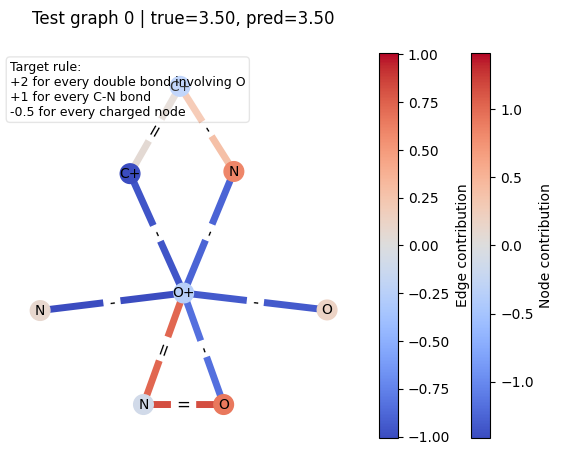

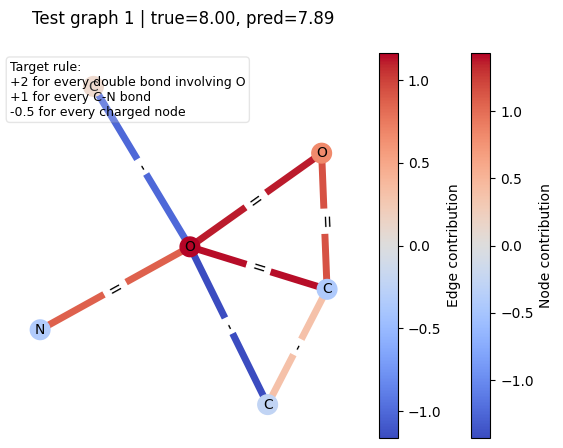

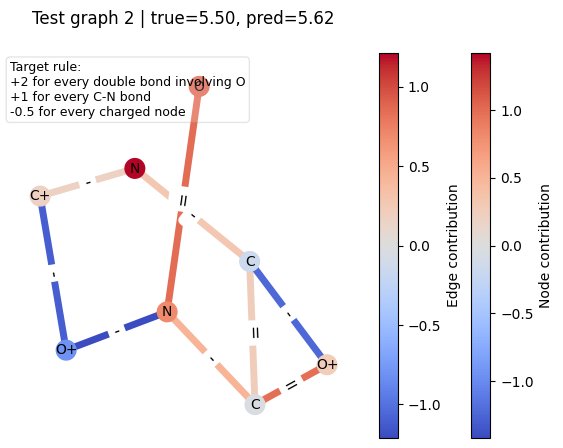

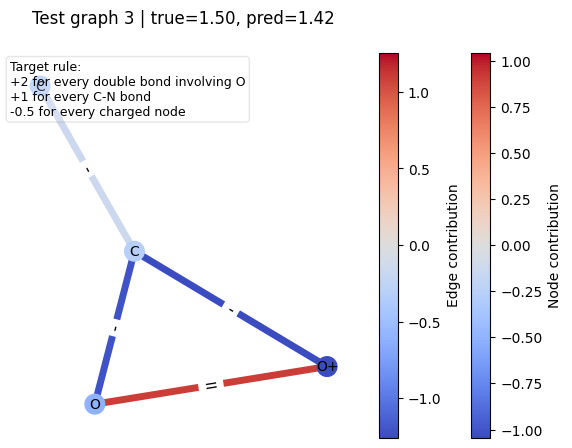

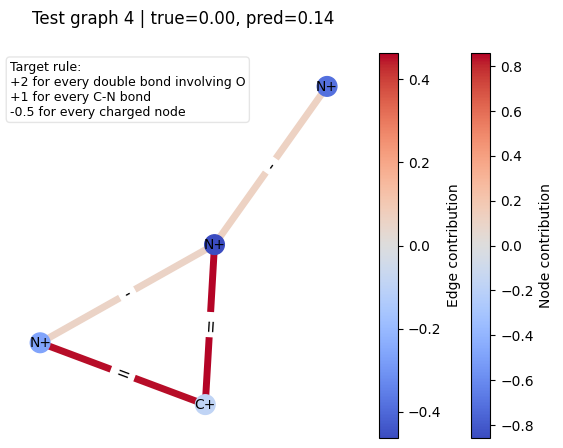

In [150]:
for i, g in enumerate(test_graphs[1:6]):
    g["rev_index"] = build_rev_index(g["edge_index"])
    plot_graph_importance(g, dmpnn, ffn, title_prefix=f"Test graph {i} | ")

While not perfect, we can see that the model is actually doing quite a good job at attributing negative scores to only the double bonds connected to an oxygen, as well as negatively scoring the charged nodes, and positively scoring C-N bonds. 

We implement a slighlty more efficient and GPU-optimized version of this model in dmpnn/model.py